<a href="https://colab.research.google.com/github/mahiiipathak/ML-LAB-/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 12.6k/12.6k [00:00<00:00, 17.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altruistdelhite04/loan-prediction-problem-dataset/versions/1

--- 1. First 5 Records of Dataset ---
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0      


--- Model Accuracy Comparison ---
Decision Tree (Gini Index) Accuracy : 0.7886
Decision Tree (Entropy) Accuracy    : 0.7805

--- Feature Importances ---
                Feature  Gini Importance  Entropy Importance
         Credit_History         0.765175            0.678571
      CoapplicantIncome         0.080001            0.102381
        ApplicantIncome         0.054150            0.066712
Property_Area_Semiurban         0.045770            0.052897
       Loan_Amount_Term         0.042343            0.041683
           Dependents_1         0.012560            0.000000
            Gender_Male         0.000000            0.000000
             LoanAmount         0.000000            0.057757
           Dependents_2         0.000000            0.000000
            Married_Yes         0.000000            0.000000
          Dependents_3+         0.000000            0.000000
 Education_Not Graduate         0.000000            0.000000
      Self_Employed_Yes         0.000000            0

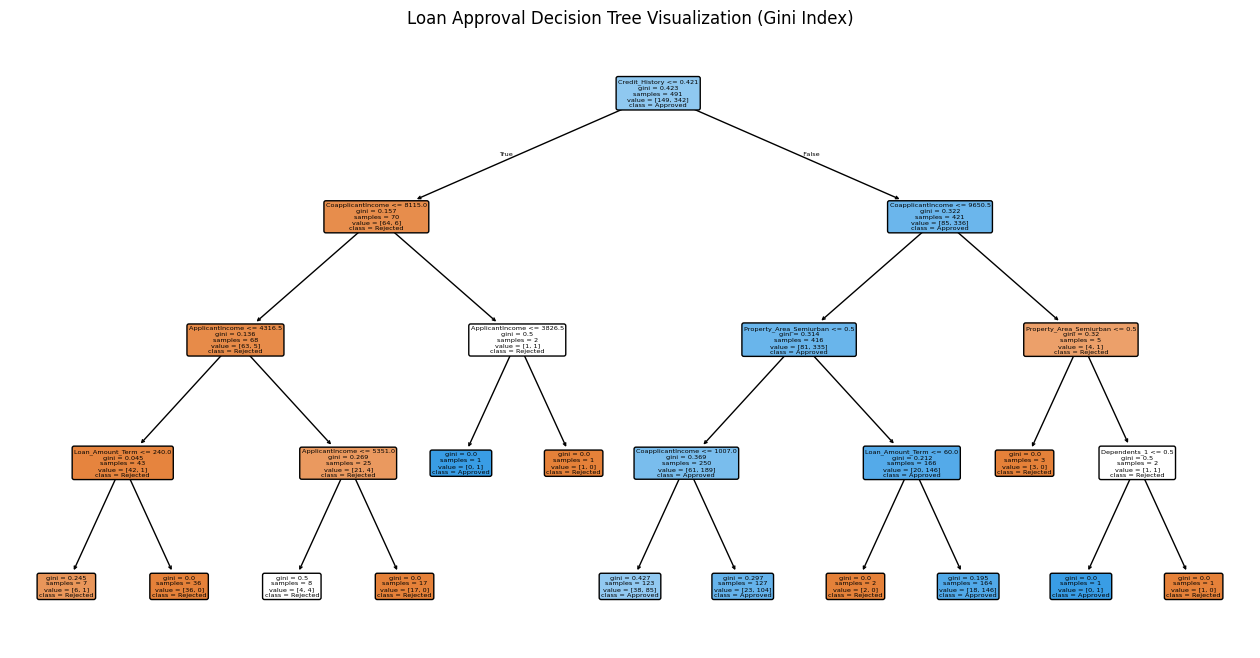

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import kagglehub

# 1. Download dataset using kagglehub
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")
print("Path to dataset files:", path)

# Locate the CSV file inside the downloaded directory (train set)
csv_files = glob.glob(os.path.join(path, "*.csv"))
train_file = [f for f in csv_files if 'train' in f.lower()]
dataset_path = train_file[0] if train_file else csv_files[0]

df = pd.read_csv(dataset_path)

print("\n--- 1. First 5 Records of Dataset ---")
print(df.head())

# Preprocessing: Drop unique ID if present
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# Target Variable setup
target_col = 'Loan_Status'
y = df[target_col].map({'Y': 1, 'N': 0})
X = df.drop(columns=[target_col])

# Impute missing values (Mean for numerical, Mode for categorical)
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=['object']).columns

if len(num_cols) > 0:
    X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])
if len(cat_cols) > 0:
    X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 2. Train Decision Tree classifier using Gini Index
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_gini.fit(X_train, y_train)

# 3. Train Decision Tree classifier using Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt_entropy.fit(X_train, y_train)

# 4. Compare classification accuracy of both models
acc_gini = accuracy_score(y_test, dt_gini.predict(X_test))
acc_entropy = accuracy_score(y_test, dt_entropy.predict(X_test))

print("\n--- Model Accuracy Comparison ---")
print(f"Decision Tree (Gini Index) Accuracy : {acc_gini:.4f}")
print(f"Decision Tree (Entropy) Accuracy    : {acc_entropy:.4f}")

# 5. Display Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Gini Importance': dt_gini.feature_importances_,
    'Entropy Importance': dt_entropy.feature_importances_
}).sort_values(by='Gini Importance', ascending=False)

print("\n--- Feature Importances ---")
print(importance_df.to_string(index=False))

# 6. Visualize the generated Decision Tree (Gini Model)
plt.figure(figsize=(16, 8))
plot_tree(dt_gini, feature_names=X_encoded.columns, class_names=['Rejected', 'Approved'], filled=True, rounded=True)
plt.title("Loan Approval Decision Tree Visualization (Gini Index)")
plt.show()